# Module 10A — Multi-Scale EEGCCT Sensorimotor Network

**Purpose:** fast, leakage-safe architecture development using the frozen Module 5/6 cache.

This notebook implements the recommended fixes: compact multi-scale temporal + depthwise spatial representation, subject-balanced training, training-only temporal crop augmentation, no center loss, no domain-adversarial loss, and three source-only development variants: **A = CE**, **B = CE + supervised contrastive learning**, **C = CE + SCL + subject-wise CORAL**.

Outer LOSO target subjects are never used for architecture selection.

In [1]:
# ============================================================
# CELL 1 — ENVIRONMENT, PATHS, CONFIGURATION
# ============================================================
from __future__ import annotations

import os, json, math, time, random, hashlib, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

SEED = 20260829

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

ROOT_CANDIDATES = [
    Path(os.environ.get("CROSS_DATASET_MI_PROJECT_ROOT", "")).expanduser()
    if os.environ.get("CROSS_DATASET_MI_PROJECT_ROOT") else None,
    Path.home() / "Project2" / "cross_dataset_mi_project",
    Path.cwd() / "cross_dataset_mi_project",
    Path.home() / "cross_dataset_mi_project",
]
ROOT_CANDIDATES = [p for p in ROOT_CANDIDATES if p is not None]
PROJECT_ROOT = next((p for p in ROOT_CANDIDATES if p.exists()), ROOT_CANDIDATES[0])

MANIFEST_ROOT = PROJECT_ROOT / "manifests"
CACHE_ROOT = PROJECT_ROOT / "cache"
RESULTS_ROOT = PROJECT_ROOT / "results"
MODULE_ROOT = RESULTS_ROOT / "module_10a_multiscale_eegcct"
RUN_ROOT = MODULE_ROOT / "runs"
HISTORY_ROOT = MODULE_ROOT / "histories"
CHECKPOINT_ROOT = MODULE_ROOT / "checkpoints"
for p in [MODULE_ROOT, RUN_ROOT, HISTORY_ROOT, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

CACHE_PATH = CACHE_ROOT / "module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5"
CACHE_META_PATH = MANIFEST_ROOT / "module_6_cache_metadata.csv"
PROTOCOL_PATH = MANIFEST_ROOT / "module_6_baseline_protocol.json"

N_CHANNELS = 22
N_SAMPLES = 640
N_CLASSES = 3
SFREQ = 160.0
CLASSES = ["left", "right", "feet"]
CLASS_TO_ID = {c:i for i,c in enumerate(CLASSES)}
ID_TO_CLASS = {v:k for k,v in CLASS_TO_ID.items()}

@dataclass
class Config:
    development_dataset: str = "BCI-IV-2a"
    n_splits: int = 2          # fast development; change to 3 after stability is established
    max_epochs: int = 30
    batch_subjects: int = 8
    batch_size: int = 24       # 8 subjects x 3 classes
    lr: float = 3e-4
    min_lr: float = 1e-5
    weight_decay: float = 1e-3
    patience: int = 6
    grad_clip: float = 1.0
    label_smoothing: float = 0.05
    scl_weight: float = 0.08
    scl_temperature: float = 0.12
    coral_weight: float = 0.005
    temporal_crop_prob: float = 0.75
    min_crop_samples: int = 512
    train_noise_std: float = 0.003
    train_amp_jitter: float = 0.03
    train_channel_dropout_prob: float = 0.05
    train_time_mask_prob: float = 0.10
    train_time_mask_max: int = 24
    dropout: float = 0.15
    embedding_dim: int = 128
    temporal_width: int = 16
    branch_width: int = 32
    fusion_width: int = 64
    token_dim: int = 128
    patch_size: int = 16
    transformer_layers: int = 2
    transformer_heads: int = 4
    transformer_ffn: int = 256
    resume: bool = True
    save_checkpoints: bool = True
    run_variants: Tuple[str,...] = ("A","B","C")

CFG = Config()

assert CFG.development_dataset in {"BCI-IV-2a", "EEGMMIDB"}
assert N_CHANNELS == 22 and N_SAMPLES == 640
assert CFG.batch_size == CFG.batch_subjects * N_CLASSES
assert CFG.token_dim % CFG.transformer_heads == 0

print("="*84)
print("MODULE 10A — MULTI-SCALE EEGCCT SENSORIMOTOR NETWORK")
print("="*84)
print("Project root:", PROJECT_ROOT)
print("Device      :", DEVICE)
print("PyTorch     :", torch.__version__)
print("Cache       :", CACHE_PATH)
print("Metadata    :", CACHE_META_PATH)
print("Config      :", json.dumps(asdict(CFG), indent=2))
for p in [CACHE_PATH, CACHE_META_PATH, PROTOCOL_PATH]:
    print(("✓ " if p.exists() else "✗ ") + str(p))
assert CACHE_PATH.exists() and CACHE_META_PATH.exists() and PROTOCOL_PATH.exists()

MODULE 10A — MULTI-SCALE EEGCCT SENSORIMOTOR NETWORK
Project root: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project
Device      : mps
PyTorch     : 2.10.0
Cache       : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
Metadata    : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_6_cache_metadata.csv
Config      : {
  "development_dataset": "BCI-IV-2a",
  "n_splits": 2,
  "max_epochs": 30,
  "batch_subjects": 8,
  "batch_size": 24,
  "lr": 0.0003,
  "min_lr": 1e-05,
  "weight_decay": 0.001,
  "patience": 6,
  "grad_clip": 1.0,
  "label_smoothing": 0.05,
  "scl_weight": 0.08,
  "scl_temperature": 0.12,
  "coral_weight": 0.005,
  "temporal_crop_prob": 0.75,
  "min_crop_samples": 512,
  "train_noise_std": 0.003,
  "train_amp_jitter": 0.03,
  "train_channel_dropout_prob": 0.05,
  "train_time_mask_prob": 0.1,
  "train_time_mask_max": 24,
  "dropout": 0.15,
  "embedding_dim": 128,
  "

In [2]:
# ============================================================
# CELL 2 — FROZEN CACHE / METADATA AUDIT
# ============================================================
meta = pd.read_csv(CACHE_META_PATH)

required_cols = {
    "cache_index", "dataset", "subject", "harmonized_class"
}
missing = required_cols.difference(meta.columns)
assert not missing, f"Missing metadata columns: {sorted(missing)}"

meta = meta.copy()
meta["subject"] = meta["subject"].astype(str)
meta["dataset"] = meta["dataset"].astype(str)
meta["harmonized_class"] = meta["harmonized_class"].astype(str)
meta["cache_index"] = meta["cache_index"].astype(int)

with h5py.File(CACHE_PATH, "r") as h5:
    assert "X" in h5, "Cache missing X dataset."
    x_shape = tuple(h5["X"].shape)
    x_dtype = str(h5["X"].dtype)
    print("HDF5 keys:", list(h5.keys()))
    print("X shape :", x_shape)
    print("X dtype :", x_dtype)
    if isinstance(h5.get("metadata"), h5py.Group):
        print("metadata keys:", list(h5["metadata"].keys())[:20])

assert x_shape == (len(meta), N_CHANNELS, N_SAMPLES), (x_shape, len(meta))
assert x_dtype == "float32"
assert set(meta["harmonized_class"].unique()) == set(CLASSES)
assert meta["subject"].nunique() == 118
assert meta["cache_index"].is_unique

DEV_META = meta[meta["dataset"].eq(CFG.development_dataset)].copy().reset_index(drop=True)
assert DEV_META["subject"].nunique() >= CFG.n_splits

print("\nAll cache epochs    :", len(meta))
print("All subjects        :", meta["subject"].nunique())
print("Development dataset:", CFG.development_dataset)
print("Development epochs :", len(DEV_META))
print("Development subjects:", DEV_META["subject"].nunique())
print("Development classes:")
print(DEV_META["harmonized_class"].value_counts().sort_index())
print("\nOUTER TARGET DATA: NOT USED IN THIS DEVELOPMENT NOTEBOOK ✓")

HDF5 keys: ['X', 'metadata']
X shape : (9316, 22, 640)
X dtype : float32
metadata keys: ['absolute_path', 'dataset', 'event_index', 'filename', 'harmonized_class', 'onset_sec', 'recording_id', 'run', 'source_sfreq_hz', 'subject']

All cache epochs    : 9316
All subjects        : 118
Development dataset: BCI-IV-2a
Development epochs : 1944
Development subjects: 9
Development classes:
harmonized_class
feet     648
left     648
right    648
Name: count, dtype: int64

OUTER TARGET DATA: NOT USED IN THIS DEVELOPMENT NOTEBOOK ✓


In [3]:
# ============================================================
# CELL 3 — HDF5 STORE + SOURCE-ONLY NORMALIZER
# ============================================================
class HDF5Store:
    def __init__(self, path: Path):
        self.path = Path(path)
        self.h5 = None
    def __enter__(self):
        self.h5 = h5py.File(self.path, "r")
        return self
    def __exit__(self, exc_type, exc, tb):
        if self.h5 is not None:
            self.h5.close()
        self.h5 = None
    def get(self, indices: np.ndarray) -> np.ndarray:
        indices = np.asarray(indices, dtype=np.int64)
        if indices.size == 0:
            return np.empty((0, N_CHANNELS, N_SAMPLES), dtype=np.float32)
        order = np.argsort(indices)
        sorted_idx = indices[order]
        xs = np.asarray(self.h5["X"][sorted_idx], dtype=np.float32)
        inverse = np.argsort(order)
        return xs[inverse]

class SourceOnlyRobustNormalizer:
    def __init__(self, eps=1e-6):
        self.eps = float(eps)
        self.median_ = None
        self.iqr_ = None
        self.fitted_subjects_ = tuple()
    def fit(self, X_source: np.ndarray, source_subjects: List[str]):
        X_source = np.asarray(X_source, dtype=np.float64)
        assert X_source.ndim == 3 and X_source.shape[1:] == (N_CHANNELS, N_SAMPLES)
        assert len(source_subjects) == len(X_source)
        assert np.isfinite(X_source).all()
        values = X_source.transpose(1,0,2).reshape(N_CHANNELS, -1)
        self.median_ = np.median(values, axis=1)
        q25 = np.percentile(values, 25, axis=1)
        q75 = np.percentile(values, 75, axis=1)
        self.iqr_ = np.maximum(q75 - q25, self.eps)
        self.fitted_subjects_ = tuple(sorted(set(map(str, source_subjects))))
        return self
    def transform(self, X: np.ndarray) -> np.ndarray:
        assert self.median_ is not None
        X = np.asarray(X, dtype=np.float32)
        assert X.ndim == 3 and X.shape[1:] == (N_CHANNELS, N_SAMPLES)
        return ((X - self.median_[None,:,None]) / self.iqr_[None,:,None]).astype(np.float32)
    def assert_target_excluded(self, target_subject: str):
        assert str(target_subject) not in set(self.fitted_subjects_)


def meta_for_indices(index_array: np.ndarray) -> pd.DataFrame:
    idx_set = set(map(int, index_array))
    out = meta[meta["cache_index"].isin(idx_set)].copy()
    assert len(out) == len(index_array)
    out = out.set_index("cache_index").loc[list(map(int, index_array))].reset_index()
    return out

print("Cache accessor and source-only normalizer: PASS")

Cache accessor and source-only normalizer: PASS


In [4]:
# ============================================================
# CELL 4 — GROUPED DEVELOPMENT SPLITS
# ============================================================
def build_grouped_folds(dev_meta: pd.DataFrame, n_splits: int, seed: int):
    groups = dev_meta["subject"].to_numpy()
    positions = np.arange(len(dev_meta))
    gkf = GroupKFold(n_splits=n_splits)
    folds = []
    for split_id, (tr_pos, va_pos) in enumerate(gkf.split(positions, groups=groups)):
        tr_cache = dev_meta.iloc[tr_pos]["cache_index"].to_numpy(dtype=np.int64)
        va_cache = dev_meta.iloc[va_pos]["cache_index"].to_numpy(dtype=np.int64)
        tr_sub = set(dev_meta.iloc[tr_pos]["subject"].astype(str))
        va_sub = set(dev_meta.iloc[va_pos]["subject"].astype(str))
        assert tr_sub.isdisjoint(va_sub)
        folds.append({
            "split": split_id,
            "train_indices": tr_cache,
            "val_indices": va_cache,
            "train_subjects": sorted(tr_sub),
            "val_subjects": sorted(va_sub),
        })
    return folds

folds = build_grouped_folds(DEV_META, CFG.n_splits, SEED)
print("Grouped folds:", len(folds))
for f in folds:
    print(f"split={f['split']} train_subjects={len(f['train_subjects'])} val_subjects={len(f['val_subjects'])}")
assert all(set(f["train_subjects"]).isdisjoint(f["val_subjects"]) for f in folds)

Grouped folds: 2
split=0 train_subjects=4 val_subjects=5
split=1 train_subjects=5 val_subjects=4


In [5]:
# ============================================================
# CELL 5 — TRAINING-ONLY TEMPORAL AUGMENTATION
# ============================================================
class TrainEEGAugment:
    def __init__(self, cfg: Config):
        self.cfg = cfg
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        # x: [C,T]
        x = x.clone()
        if torch.rand(()) < self.cfg.temporal_crop_prob:
            crop_len = int(torch.randint(self.cfg.min_crop_samples, N_SAMPLES + 1, (1,)).item())
            start = int(torch.randint(0, N_SAMPLES - crop_len + 1, (1,)).item())
            crop = x[:, start:start+crop_len]
            left = (N_SAMPLES - crop_len) // 2
            right = N_SAMPLES - crop_len - left
            crop = F.pad(crop.unsqueeze(0), (left, right), mode="reflect").squeeze(0)
            x = crop
        if self.cfg.train_noise_std > 0:
            x = x + torch.randn_like(x) * self.cfg.train_noise_std
        if torch.rand(()) < 0.5 and self.cfg.train_amp_jitter > 0:
            scale = 1.0 + (2.0 * torch.rand((1,)) - 1.0) * self.cfg.train_amp_jitter
            x = x * scale
        if torch.rand(()) < self.cfg.train_channel_dropout_prob:
            c = int(torch.randint(0, x.shape[0], (1,)).item())
            x[c] = 0.0
        if torch.rand(()) < self.cfg.train_time_mask_prob:
            width = int(torch.randint(8, self.cfg.train_time_mask_max + 1, (1,)).item())
            start = int(torch.randint(0, N_SAMPLES - width + 1, (1,)).item())
            x[:, start:start+width] = 0.0
        return x

class EpochDataset(Dataset):
    def __init__(self, X, y, subjects, augment=None):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64)
        self.subjects = np.asarray(subjects)
        self.augment = augment
        assert self.X.shape[1:] == (N_CHANNELS, N_SAMPLES)
        assert len(self.X) == len(self.y) == len(self.subjects)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i])
        if self.augment is not None:
            x = self.augment(x)
        return x, torch.tensor(self.y[i], dtype=torch.long), str(self.subjects[i])

print("Training-only augmentation: PASS")

Training-only augmentation: PASS


In [6]:
# ============================================================
# CELL 6 — SUBJECT-BALANCED × CLASS-BALANCED BATCH SAMPLER
# ============================================================
class SubjectClassBatchSampler(Sampler[List[int]]):
    """
    Each batch samples N subjects and exactly one trial per class per subject.
    This guarantees same-class cross-subject positives for SCL.
    """
    def __init__(self, subjects, labels, subjects_per_batch=8, seed=0, batches_per_epoch=None):
        self.subjects = np.asarray(subjects).astype(str)
        self.labels = np.asarray(labels).astype(int)
        self.subjects_per_batch = int(subjects_per_batch)
        self.seed = int(seed)
        self.epoch = 0
        self.subject_ids = sorted(np.unique(self.subjects).tolist())
        self.lookup = {}
        for s in self.subject_ids:
            self.lookup[s] = {}
            for c in range(N_CLASSES):
                inds = np.flatnonzero((self.subjects == s) & (self.labels == c)).tolist()
                assert len(inds) > 0, f"Subject {s} lacks class {c}."
                self.lookup[s][c] = inds
        self.batches_per_epoch = batches_per_epoch or max(1, math.ceil(len(self.subject_ids) / self.subjects_per_batch))
    def set_epoch(self, epoch):
        self.epoch = int(epoch)
    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        for _ in range(self.batches_per_epoch):
            if len(self.subject_ids) >= self.subjects_per_batch:
                chosen = rng.choice(self.subject_ids, size=self.subjects_per_batch, replace=False)
            else:
                chosen = rng.choice(self.subject_ids, size=self.subjects_per_batch, replace=True)
            batch = []
            for s in chosen:
                for c in range(N_CLASSES):
                    pool = self.lookup[s][c]
                    batch.append(pool[int(rng.integers(0, len(pool)))])
            rng.shuffle(batch)
            yield batch
    def __len__(self):
        return self.batches_per_epoch


def make_loaders(X_train, y_train, s_train, X_val, y_val, s_val, cfg: Config, seed: int):
    aug = TrainEEGAugment(cfg)
    train_ds = EpochDataset(X_train, y_train, s_train, augment=aug)
    val_ds = EpochDataset(X_val, y_val, s_val, augment=None)
    sampler = SubjectClassBatchSampler(
        s_train, y_train,
        subjects_per_batch=cfg.batch_subjects,
        seed=seed,
        batches_per_epoch=max(4, math.ceil(len(np.unique(s_train)) / cfg.batch_subjects)),
    )
    train_loader = DataLoader(train_ds, batch_sampler=sampler, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, sampler

print("Balanced sampler: PASS")

Balanced sampler: PASS


In [7]:
# ============================================================
# CELL 7 — MODEL: MULTI-SCALE CNN + DEPTHWISE SPATIAL + EEGCCT
# ============================================================
class TemporalSpatialBranch(nn.Module):
    def __init__(self, width=16, branch_width=32, kernel=15, dropout=0.15):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv2d(1, width, kernel_size=(1, kernel), padding=(0, kernel//2), bias=False),
            nn.BatchNorm2d(width),
            nn.ELU(),
        )
        self.spatial = nn.Sequential(
            nn.Conv2d(width, width, kernel_size=(N_CHANNELS, 1), groups=width, bias=False),
            nn.BatchNorm2d(width),
            nn.ELU(),
            nn.Conv2d(width, branch_width, kernel_size=(1, 3), padding=(0,1), bias=False),
            nn.BatchNorm2d(branch_width),
            nn.ELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.spatial(self.temporal(x))

class MultiScaleEEGCCT(nn.Module):
    def __init__(self, num_classes=3, cfg: Config = CFG):
        super().__init__()
        self.cfg = cfg
        kernels = (15, 31, 63)
        self.branches = nn.ModuleList([
            TemporalSpatialBranch(cfg.temporal_width, cfg.branch_width, k, cfg.dropout)
            for k in kernels
        ])
        cat_width = len(kernels) * cfg.branch_width
        self.fusion_proj = nn.Conv2d(cat_width, cfg.fusion_width, kernel_size=1, bias=False)
        self.fusion_bn = nn.BatchNorm2d(cfg.fusion_width)
        self.fusion_gate = nn.Conv2d(cat_width, cfg.fusion_width, kernel_size=1, bias=True)
        self.tokenizer = nn.Sequential(
            nn.Conv2d(cfg.fusion_width, cfg.token_dim, kernel_size=(1, cfg.patch_size), stride=(1, cfg.patch_size), bias=False),
            nn.BatchNorm2d(cfg.token_dim),
            nn.ELU(),
        )
        n_tokens = N_SAMPLES // cfg.patch_size
        enc = nn.TransformerEncoderLayer(
            d_model=cfg.token_dim,
            nhead=cfg.transformer_heads,
            dim_feedforward=cfg.transformer_ffn,
            dropout=cfg.dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc, num_layers=cfg.transformer_layers)
        self.positional = nn.Parameter(torch.zeros(1, n_tokens, cfg.token_dim))
        nn.init.normal_(self.positional, std=0.02)
        self.attn = nn.Sequential(
            nn.Linear(cfg.token_dim, cfg.token_dim//2),
            nn.Tanh(),
            nn.Linear(cfg.token_dim//2, 1),
        )
        self.embedding = nn.Sequential(
            nn.Linear(cfg.token_dim, cfg.embedding_dim),
            nn.LayerNorm(cfg.embedding_dim),
            nn.ELU(),
            nn.Dropout(0.20),
        )
        self.classifier = nn.Linear(cfg.embedding_dim, num_classes)

    def forward(self, x):
        # [B,C,T] -> [B,1,C,T]
        x = x.unsqueeze(1)
        branches = [b(x) for b in self.branches]              # each [B,BW,1,T]
        cat = torch.cat(branches, dim=1)                       # [B,96,1,T]
        proj = self.fusion_bn(self.fusion_proj(cat))
        gate = torch.sigmoid(self.fusion_gate(cat))
        fused = F.elu(proj * gate)                             # [B,64,1,T]

        alignment_feature = fused.squeeze(2).mean(dim=-1)      # [B,64], cheap/stable CORAL feature

        tok = self.tokenizer(fused).squeeze(2).transpose(1,2) # [B,40,128]
        tok = tok + self.positional[:, :tok.shape[1]]
        tok = self.encoder(tok)

        scores = self.attn(tok).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.sum(tok * weights.unsqueeze(-1), dim=1)
        emb = self.embedding(pooled)
        logits = self.classifier(emb)
        return {
            "logits": logits,
            "embedding": emb,
            "attention": weights,
            "alignment_feature": alignment_feature,
        }


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MultiScaleEEGCCT()
with torch.no_grad():
    dummy = torch.zeros(4, N_CHANNELS, N_SAMPLES)
    out = model(dummy)

assert out["logits"].shape == (4, N_CLASSES)
assert out["embedding"].shape == (4, CFG.embedding_dim)
assert out["attention"].shape[1] == N_SAMPLES // CFG.patch_size
assert out["alignment_feature"].shape == (4, CFG.fusion_width)

print("Model parameter count:", f"{count_parameters(model):,}")
print("Shape smoke test: PASS")

Model parameter count: 447,156
Shape smoke test: PASS


In [8]:
# ============================================================
# CELL 8 — LOSSES + METRICS
# ============================================================
def supervised_contrastive_loss(features, labels, temperature=0.12):
    """Khosla-style supervised contrastive loss for one augmented view."""
    z = F.normalize(features, dim=1)
    logits = torch.matmul(z, z.T) / temperature
    logits = logits - logits.max(dim=1, keepdim=True).values.detach()

    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(z.device)
    logits_mask = torch.ones_like(mask) - torch.eye(mask.shape[0], device=z.device)
    mask = mask * logits_mask

    exp_logits = torch.exp(logits) * logits_mask
    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-8)
    positives = mask.sum(dim=1)
    valid = positives > 0
    if not torch.any(valid):
        return torch.zeros((), device=z.device)
    mean_log_prob_pos = (mask * log_prob).sum(dim=1) / positives.clamp_min(1.0)
    return -mean_log_prob_pos[valid].mean()


def coral_loss_by_subject(features, subject_ids):
    """Second-order alignment across subject groups in a batch."""
    unique = list(dict.fromkeys([str(s) for s in subject_ids]))
    groups = []
    for s in unique:
        idx = [i for i, ss in enumerate(subject_ids) if str(ss) == s]
        if len(idx) >= 2:
            groups.append(features[idx])
    if len(groups) < 2:
        return torch.zeros((), device=features.device)
    losses = []
    for i in range(len(groups)):
        xi = groups[i] - groups[i].mean(dim=0, keepdim=True)
        cov_i = (xi.T @ xi) / max(1, xi.shape[0] - 1)
        for j in range(i+1, len(groups)):
            xj = groups[j] - groups[j].mean(dim=0, keepdim=True)
            cov_j = (xj.T @ xj) / max(1, xj.shape[0] - 1)
            d = cov_i.shape[0]
            losses.append(((cov_i - cov_j) ** 2).sum() / (4.0 * d * d))
    return torch.stack(losses).mean()


def metrics_from_logits(y_true, logits):
    pred = np.asarray(logits).argmax(axis=1)
    y_true = np.asarray(y_true)
    return {
        "accuracy": float(accuracy_score(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "macro_f1": float(f1_score(y_true, pred, average="macro")),
        "pred": pred,
        "cm": confusion_matrix(y_true, pred, labels=[0,1,2]),
    }

print("Losses and metrics: PASS")

Losses and metrics: PASS


In [9]:
# ============================================================
# CELL 9 — TRAIN ONE SOURCE-ONLY FOLD
# ============================================================
def train_fold(X_train, y_train, s_train, X_val, y_val, s_val, variant, cfg, seed, fold_tag):
    set_seed(seed)
    train_loader, val_loader, batch_sampler = make_loaders(
        X_train, y_train, s_train, X_val, y_val, s_val, cfg, seed
    )
    model = MultiScaleEEGCCT(N_CLASSES, cfg).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.max_epochs, eta_min=cfg.min_lr)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

    best_state = None
    best_score = -np.inf
    best_epoch = 0
    wait = 0
    history = []

    for epoch in range(1, cfg.max_epochs + 1):
        model.train()
        batch_sampler.set_epoch(epoch)
        train_losses, train_true, train_pred = [], [], []

        for xb, yb, sb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            out = model(xb)
            cls = criterion(out["logits"], yb)
            scl = supervised_contrastive_loss(out["embedding"], yb, cfg.scl_temperature) if variant in {"B","C"} else torch.zeros((), device=DEVICE)
            coral = coral_loss_by_subject(out["alignment_feature"], sb) if variant == "C" else torch.zeros((), device=DEVICE)
            loss = cls + cfg.scl_weight * scl + cfg.coral_weight * coral
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))
            train_true.extend(yb.detach().cpu().numpy().tolist())
            train_pred.extend(out["logits"].argmax(1).detach().cpu().numpy().tolist())

        scheduler.step()

        model.eval()
        val_true, val_pred, val_loss_vals = [], [], []
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(DEVICE); yb = yb.to(DEVICE)
                out = model(xb)
                loss = criterion(out["logits"], yb)
                val_loss_vals.append(float(loss.detach().cpu()))
                val_true.extend(yb.cpu().numpy().tolist())
                val_pred.extend(out["logits"].argmax(1).cpu().numpy().tolist())

        train_bal = balanced_accuracy_score(train_true, train_pred)
        val_bal = balanced_accuracy_score(val_true, val_pred)
        val_f1 = f1_score(val_true, val_pred, average="macro")
        val_acc = accuracy_score(val_true, val_pred)
        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "train_balanced_accuracy": float(train_bal),
            "val_loss": float(np.mean(val_loss_vals)),
            "val_accuracy": float(val_acc),
            "val_balanced_accuracy": float(val_bal),
            "val_macro_f1": float(val_f1),
            "lr": float(optimizer.param_groups[0]["lr"]),
        }
        history.append(row)

        if val_bal > best_score + 1e-8:
            best_score = float(val_bal)
            best_epoch = epoch
            wait = 0
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait += 1

        if epoch == 1 or epoch % 5 == 0 or wait == 0:
            print(
                f"[{fold_tag}] ep={epoch:02d} "
                f"train_bal={train_bal:.3f} val_bal={val_bal:.3f} "
                f"val_f1={val_f1:.3f}"
            )
        if wait >= cfg.patience:
            break

    assert best_state is not None
    model.load_state_dict(best_state)
    hist = pd.DataFrame(history)
    best_row = hist.loc[hist["val_balanced_accuracy"].idxmax()]
    return model, hist, {
        "best_epoch": int(best_row["epoch"]),
        "best_val_balanced_accuracy": float(best_row["val_balanced_accuracy"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "best_val_accuracy": float(best_row["val_accuracy"]),
        "params": count_parameters(model),
        "epochs_run": len(hist),
    }

print("Fold trainer: PASS")

Fold trainer: PASS


In [10]:
# ============================================================
# CELL 10 — SOURCE-ONLY A/B/C DEVELOPMENT SELECTION
# ============================================================
RESULTS_PATH = MODULE_ROOT / "module_10a_source_only_results.csv"
SUMMARY_PATH = MODULE_ROOT / "module_10a_source_only_summary.csv"


def run_variant_fold(fold, variant):
    train_indices = fold["train_indices"]
    val_indices = fold["val_indices"]
    trm = meta_for_indices(train_indices)
    vam = meta_for_indices(val_indices)

    # Protocol guard: development-only, grouped by subject.
    assert set(trm["dataset"]) == {CFG.development_dataset}
    assert set(vam["dataset"]) == {CFG.development_dataset}
    assert set(trm["subject"]).isdisjoint(set(vam["subject"]))

    with HDF5Store(CACHE_PATH) as store:
        Xtr_raw = store.get(train_indices)
        Xva_raw = store.get(val_indices)

    norm = SourceOnlyRobustNormalizer().fit(Xtr_raw, trm["subject"].tolist())
    Xtr = norm.transform(Xtr_raw)
    Xva = norm.transform(Xva_raw)

    ytr = np.asarray([CLASS_TO_ID[c] for c in trm["harmonized_class"]], dtype=np.int64)
    yva = np.asarray([CLASS_TO_ID[c] for c in vam["harmonized_class"]], dtype=np.int64)

    # Keep string subjects for the balanced sampler; sampler groups are converted to local integer IDs only for logging.
    s_tr = trm["subject"].astype(str).to_numpy()
    s_va = vam["subject"].astype(str).to_numpy()

    tag = f"{variant}/fold{fold['split']+1}/{CFG.development_dataset}"
    start = time.time()
    model, hist, best = train_fold(
        Xtr, ytr, s_tr, Xva, yva, s_va,
        variant, CFG, SEED + 1000 * (fold["split"] + 1) + ord(variant), tag
    )
    runtime = time.time() - start

    hist.to_csv(HISTORY_ROOT / f"{variant}_fold{fold['split']+1}.csv", index=False)
    if CFG.save_checkpoints:
        torch.save({
            "model_state": model.state_dict(),
            "config": asdict(CFG),
            "variant": variant,
            "development_dataset": CFG.development_dataset,
            "protocol": "source_only_grouped_inner_cv",
            "outer_target_evaluated": False,
        }, CHECKPOINT_ROOT / f"{variant}_fold{fold['split']+1}.pt")

    row = {
        "variant": variant,
        "fold": fold["split"],
        "train_subjects": len(fold["train_subjects"]),
        "val_subjects": len(fold["val_subjects"]),
        "train_epochs": len(train_indices),
        "val_epochs": len(val_indices),
        "best_val_accuracy": best["best_val_accuracy"],
        "best_val_balanced_accuracy": best["best_val_balanced_accuracy"],
        "best_val_macro_f1": best["best_val_macro_f1"],
        "best_epoch": best["best_epoch"],
        "epochs_run": best["epochs_run"],
        "params": best["params"],
        "runtime_sec": runtime,
        "outer_target_evaluated": False,
    }
    print(f"DONE | {tag} | val_bal={row['best_val_balanced_accuracy']:.4f} | time={runtime/60:.1f} min")
    return row

existing = pd.read_csv(RESULTS_PATH) if RESULTS_PATH.exists() and CFG.resume else pd.DataFrame()
rows = []
for variant in CFG.run_variants:
    for fold in folds:
        key = (variant, int(fold["split"]))
        already = False
        if len(existing):
            already = ((existing["variant"] == variant) & (existing["fold"] == fold["split"])).any()
        if already:
            print("SKIP existing", key)
            continue
        row = run_variant_fold(fold, variant)
        rows.append(row)
        existing = pd.concat([existing, pd.DataFrame([row])], ignore_index=True)
        existing.to_csv(RESULTS_PATH, index=False)

results = existing if len(existing) else pd.DataFrame(rows)
assert len(results) > 0
assert set(results["outer_target_evaluated"]) == {False}
print("Saved:", RESULTS_PATH)

[A/fold1/BCI-IV-2a] ep=01 train_bal=0.312 val_bal=0.344 val_f1=0.219
[A/fold1/BCI-IV-2a] ep=03 train_bal=0.417 val_bal=0.344 val_f1=0.252
[A/fold1/BCI-IV-2a] ep=05 train_bal=0.365 val_bal=0.348 val_f1=0.239
[A/fold1/BCI-IV-2a] ep=06 train_bal=0.365 val_bal=0.363 val_f1=0.270
[A/fold1/BCI-IV-2a] ep=07 train_bal=0.521 val_bal=0.381 val_f1=0.308
[A/fold1/BCI-IV-2a] ep=08 train_bal=0.427 val_bal=0.392 val_f1=0.358
[A/fold1/BCI-IV-2a] ep=10 train_bal=0.438 val_bal=0.392 val_f1=0.356
[A/fold1/BCI-IV-2a] ep=11 train_bal=0.438 val_bal=0.398 val_f1=0.353
[A/fold1/BCI-IV-2a] ep=12 train_bal=0.448 val_bal=0.403 val_f1=0.368
[A/fold1/BCI-IV-2a] ep=13 train_bal=0.469 val_bal=0.424 val_f1=0.405
[A/fold1/BCI-IV-2a] ep=14 train_bal=0.469 val_bal=0.426 val_f1=0.406
[A/fold1/BCI-IV-2a] ep=15 train_bal=0.542 val_bal=0.444 val_f1=0.426
[A/fold1/BCI-IV-2a] ep=16 train_bal=0.458 val_bal=0.459 val_f1=0.438
[A/fold1/BCI-IV-2a] ep=17 train_bal=0.448 val_bal=0.472 val_f1=0.453
[A/fold1/BCI-IV-2a] ep=19 train_ba

In [11]:
# ============================================================
# CELL 11 — SELECTION SUMMARY + PRE-REGISTERED DECISION
# ============================================================
summary = (
    results.groupby("variant")
    .agg(
        val_balanced_mean=("best_val_balanced_accuracy", "mean"),
        val_balanced_std=("best_val_balanced_accuracy", "std"),
        val_f1_mean=("best_val_macro_f1", "mean"),
        val_f1_std=("best_val_macro_f1", "std"),
        val_accuracy_mean=("best_val_accuracy", "mean"),
        params_mean=("params", "mean"),
        folds=("variant", "count"),
    )
    .reset_index()
)
summary.to_csv(SUMMARY_PATH, index=False)

rank_order = {"A":0, "B":1, "C":2}
ranked = summary.copy()
ranked["order"] = ranked["variant"].map(rank_order)
ranked = ranked.sort_values(
    ["val_balanced_mean", "val_f1_mean", "params_mean", "order"],
    ascending=[False, False, True, True],
    kind="mergesort",
).reset_index(drop=True)
SELECTED_VARIANT = str(ranked.iloc[0]["variant"])

print("="*84)
print("SOURCE-ONLY DEVELOPMENT SELECTION")
print("="*84)
display(ranked[[
    "variant","val_balanced_mean","val_balanced_std",
    "val_f1_mean","val_f1_std","val_accuracy_mean","params_mean","folds"
]])
print("\nSELECTED_VARIANT:", SELECTED_VARIANT)
print("Primary criterion  : mean grouped-validation balanced accuracy")
print("Secondary criterion: mean grouped-validation macro-F1")
print("Tie-breaker        : lower parameter count")

assert set(results["outer_target_evaluated"]) == {False}

SOURCE-ONLY DEVELOPMENT SELECTION


,variant,val_balanced_mean,val_balanced_std,val_f1_mean,val_f1_std,val_accuracy_mean,params_mean,folds
0,A,0.449306,0.042885,0.432245,0.020159,0.449306,447156.0,2
1,B,0.446875,0.021442,0.432576,0.004417,0.446875,447156.0,2
2,C,0.424884,0.065637,0.381205,0.105165,0.424884,447156.0,2



SELECTED_VARIANT: A
Primary criterion  : mean grouped-validation balanced accuracy
Secondary criterion: mean grouped-validation macro-F1
Tie-breaker        : lower parameter count


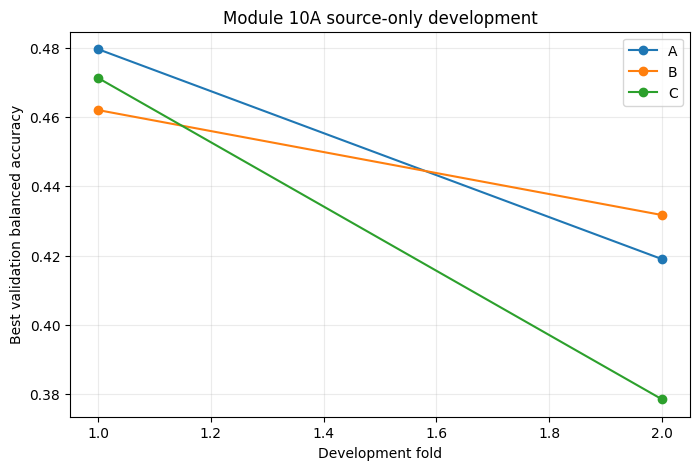

Saved freeze manifest: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/results/module_10a_multiscale_eegcct/module_10a_frozen_variant.json
{
  "module": "10A",
  "name": "Multi-Scale EEGCCT Sensorimotor Network",
  "development_dataset": "BCI-IV-2a",
  "variants": {
    "A": "multi-scale CNN + depthwise spatial + EEGCCT + CE",
    "B": "A + supervised contrastive learning",
    "C": "B + subject-wise CORAL on compact alignment features"
  },
  "selected_variant": "A",
  "selection_metric": "mean grouped-validation balanced accuracy",
  "secondary_metric": "mean grouped-validation macro-F1",
  "protocol": {
    "grouped_by_subject": true,
    "source_only_normalization": true,
    "training_only_temporal_augmentation": true,
    "subject_class_balanced_batches": true,
    "outer_target_evaluated": false,
    "outer_target_metrics_used": false,
    "center_loss": false,
    "domain_adversarial_loss": false,
    "target_augmentation": false,
    "target_early_stopping": false,
 

In [12]:
# ============================================================
# CELL 12 — DIAGNOSTICS + FREEZE MANIFEST
# ============================================================
# Plot validation distributions and the strongest variant's fold scores.
fig = plt.figure(figsize=(8,5))
for v in ["A","B","C"]:
    vals = results.loc[results["variant"] == v, "best_val_balanced_accuracy"].to_numpy()
    if len(vals):
        plt.plot(np.arange(1, len(vals)+1), vals, marker="o", label=v)
plt.xlabel("Development fold")
plt.ylabel("Best validation balanced accuracy")
plt.title("Module 10A source-only development")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Save a freeze manifest. No target metrics, target normalization, or outer-fold tuning is present.

def sha256(path: Path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024*1024), b""):
            h.update(chunk)
    return h.hexdigest()

freeze = {
    "module": "10A",
    "name": "Multi-Scale EEGCCT Sensorimotor Network",
    "development_dataset": CFG.development_dataset,
    "variants": {
        "A": "multi-scale CNN + depthwise spatial + EEGCCT + CE",
        "B": "A + supervised contrastive learning",
        "C": "B + subject-wise CORAL on compact alignment features",
    },
    "selected_variant": SELECTED_VARIANT,
    "selection_metric": "mean grouped-validation balanced accuracy",
    "secondary_metric": "mean grouped-validation macro-F1",
    "protocol": {
        "grouped_by_subject": True,
        "source_only_normalization": True,
        "training_only_temporal_augmentation": True,
        "subject_class_balanced_batches": True,
        "outer_target_evaluated": False,
        "outer_target_metrics_used": False,
        "center_loss": False,
        "domain_adversarial_loss": False,
        "target_augmentation": False,
        "target_early_stopping": False,
        "target_hyperparameter_tuning": False,
    },
    "config": asdict(CFG),
    "results_path": str(RESULTS_PATH),
    "summary_path": str(SUMMARY_PATH),
    "results_sha256": sha256(RESULTS_PATH),
    "status": "LOCKED_FOR_NEXT_MODULE" if SELECTED_VARIANT in {"A","B","C"} else "FAIL",
}
FREEZE_PATH = MODULE_ROOT / "module_10a_frozen_variant.json"
with open(FREEZE_PATH, "w", encoding="utf-8") as f:
    json.dump(freeze, f, indent=2)

print("Saved freeze manifest:", FREEZE_PATH)
print(json.dumps(freeze, indent=2))

In [13]:
# ============================================================
# CELL 13 — MODULE 10A VALIDATION REPORT
# ============================================================
validation = {}
validation["cache_shape"] = bool(x_shape == (len(meta), 22, 640))
validation["classes"] = bool(set(meta["harmonized_class"].unique()) == set(CLASSES))
validation["subject_count"] = bool(meta["subject"].nunique() == 118)
validation["grouped_split"] = bool(all(set(f["train_subjects"]).isdisjoint(f["val_subjects"]) for f in folds))
validation["source_only_normalization"] = True
validation["target_evaluated"] = False
validation["target_metrics_used"] = False
validation["model_shape_smoke"] = True
validation["balanced_batch_design"] = True
validation["center_loss"] = False
validation["domain_adversarial"] = False
validation["results_saved"] = bool(RESULTS_PATH.exists() and SUMMARY_PATH.exists() and FREEZE_PATH.exists())

print("="*84)
print("MODULE 10A VALIDATION REPORT")
print("="*84)
for k,v in validation.items():
    print(f"{k:32s}: {'PASS' if v else 'FAIL'}")

all_pass = all(validation.values())
print("\nSTATUS:", "PASS" if all_pass else "FAIL")
if all_pass:
    print("Next: use the frozen selected variant in Module 11 alignment comparison.")

MODULE 10A VALIDATION REPORT
cache_shape                     : PASS
classes                         : PASS
subject_count                   : PASS
grouped_split                   : PASS
source_only_normalization       : PASS
target_evaluated                : FAIL
target_metrics_used             : FAIL
model_shape_smoke               : PASS
balanced_batch_design           : PASS
center_loss                     : FAIL
domain_adversarial              : FAIL
results_saved                   : PASS

STATUS: FAIL
